# Prototype Verifikasi Ijazah: OCR Nomor Ijazah + Deteksi Tanda Tangan

Notebook ini membaca satu citra ijazah, lalu mengeluarkan dua hal: **nomor ijazah** (lewat OCR) dan **status tanda tangan pejabat penandatangan** (PRESENT atau ABSENT, lewat pengolahan citra klasik).

Contoh output yang dituju:

```
Input  : ijazah_001.jpg
Nomor Ijazah : 571012022000056
Tanda Tangan : PRESENT
```

Pipeline yang dipakai persis mengikuti diagram tugas:

```
Citra Ijazah -> Grayscale -> Image Enhancement -> +-> Area Nomor -> Enhancement -> OCR -> Nomor Ijazah
                                                  +-> Area TTD   -> Thresholding -> Morphology -> Signature Detection
                                                                                     => Hasil Verifikasi
```

**Cara pakai singkat:** jalankan semua sel dari atas ke bawah (Run All). Sel pertama akan memasang mesin OCR dan library yang dibutuhkan, jadi tidak ada langkah download manual.

## 0. Instalasi (otomatis)

OCR memakai **Tesseract**. Tesseract itu program, bukan sekadar library Python, jadi ia harus ada di mesin. Bedanya dengan file `.py`, di notebook pemasangan itu cukup ditaruh di sel pertama dan jalan sendiri saat Run All. Di Google Colab atau Linux, sel di bawah memasang semuanya. Di Windows atau macOS, pasang Tesseract satu kali saja (petunjuk ada di README), sisanya tetap otomatis.

In [1]:
import sys, shutil, subprocess, platform

def sh(cmd):
    subprocess.run(cmd, shell=True, check=False)

# 1) library Python
try:
    import cv2, numpy, pandas, matplotlib, pytesseract   # sudah ada? lewati pip
except ImportError:
    pkgs = "opencv-python-headless numpy pandas matplotlib pytesseract"
    r = subprocess.run(f"{sys.executable} -m pip install -q {pkgs}", shell=True)
    if r.returncode != 0:   # sebagian sistem Linux memblokir pip global (PEP 668)
        sh(f"{sys.executable} -m pip install -q --break-system-packages {pkgs}")

# 2) mesin OCR Tesseract
if shutil.which("tesseract") is None:
    if platform.system() == "Linux":
        sh("apt-get -qq update && apt-get -qq install -y tesseract-ocr")
    else:
        print("Tesseract belum terpasang. Lihat README bagian Windows/macOS, lalu jalankan ulang sel ini.")

print("Tesseract:", shutil.which("tesseract") or "TIDAK DITEMUKAN")

Tesseract: /usr/bin/tesseract


In [2]:
import os, re, glob, warnings
import cv2, numpy as np, pandas as pd, pytesseract
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# Windows saja: buka komentar baris di bawah dan sesuaikan path-nya
# pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

DATA_DIR    = "data"
RESULT_DIR  = "results"
os.makedirs(RESULT_DIR, exist_ok=True)
print("OpenCV", cv2.__version__, "| Tesseract", pytesseract.get_tesseract_version())

OpenCV 4.13.0 | Tesseract 5.3.4


## 1. Penjelasan metode

| Tahap | Metode | Alasan |
|---|---|---|
| Koreksi orientasi | Coba 4 rotasi (0, 90, 180, 270), OCR cepat pada gambar kecil, pilih rotasi yang paling banyak mengandung kata kunci (*ijazah, universitas, nomor, rektor, dekan*) | Hasil scan sering miring 90 derajat. Contoh ijazah pada tugas ini juga begitu. |
| Grayscale | `cv2.cvtColor` BGR ke gray | Warna tidak membawa informasi untuk teks dan tinta, dan semua langkah berikutnya bekerja di satu kanal. |
| Enhancement umum | Bilateral filter ringan | Meredam noise scan tapi tepi huruf tetap tajam. |
| Area nomor | Crop ROI relatif (proporsi lebar dan tinggi) di pojok kiri bawah | Posisi nomor pada template ijazah konsisten, jadi ROI relatif tetap berlaku untuk resolusi berbeda. |
| Enhancement area nomor | **11 metode dibandingkan** (tabel di bagian 5) | Metode terbaik dipilih berdasarkan nilai CER, bukan perasaan. |
| OCR | Tesseract, `--psm 7` (satu baris), whitelist angka 0-9 | Nomor ijazah hanya terdiri dari digit dan berada di satu baris. |
| Area tanda tangan | Crop ROI relatif di atas nama Rektor | Tanda tangan Rektor berada di antara tulisan "Rektor" dan nama pejabat. |
| Thresholding | Estimasi latar (dilasi + median blur), selisih mutlak dengan citra, lalu Otsu dengan batas kontras minimum | Kertas ijazah punya pola guilloche halus. Dengan membuang latar dulu, hanya tinta gelap yang tersisa. Batas kontras minimum mencegah pola kertas dianggap tinta saat area memang kosong. |
| Morphology | Opening 3x3 (hapus bintik), lalu closing 9x9 (sambung goresan putus) | Goresan tanda tangan tipis sering terputus setelah thresholding. |
| Signature detection | Connected components. Komponen terbesar harus punya luas minimal 0,4 persen ROI dan lebar minimal 25 persen ROI | Tanda tangan itu goresan besar yang menyambung, bedanya jelas dari noise yang kecil dan tersebar. |
| CER | Character Error Rate = jarak Levenshtein / panjang ground truth | Metrik standar untuk menilai kualitas OCR tingkat karakter. 0 berarti sempurna. |

## 2. Fungsi-fungsi bantu

In [3]:
# ---------- CER ----------
def cer(ref, hyp):
    """Character Error Rate: Levenshtein(ref, hyp) / len(ref)."""
    n, m = len(ref), len(hyp)
    d = list(range(m + 1))
    for i in range(1, n + 1):
        prev, d[0] = d[0], i
        for j in range(1, m + 1):
            cur = d[j]
            d[j] = min(d[j] + 1, d[j - 1] + 1, prev + (ref[i - 1] != hyp[j - 1]))
            prev = cur
    return d[m] / max(n, 1)

# ---------- Orientasi ----------
KEYWORDS = ["ijazah", "universitas", "nomor", "rektor", "dekan", "memberikan"]

def fix_orientation(img):
    best, best_score = img, -1
    for k in [None, cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE]:
        r = img if k is None else cv2.rotate(img, k)
        small = cv2.resize(r, None, fx=0.4, fy=0.4)
        txt = pytesseract.image_to_string(cv2.cvtColor(small, cv2.COLOR_BGR2GRAY), config="--psm 6").lower()
        score = sum(w in txt for w in KEYWORDS)
        if score > best_score:
            best, best_score = r, score
        if score >= 4:
            break
    return best

# ---------- ROI relatif: (x0, x1, y0, y1) dalam proporsi 0..1 ----------
NUM_BOX = (0.03, 0.42, 0.89, 0.97)   # "Nomor ijazah: ..." pojok kiri bawah
SIG_BOX = (0.10, 0.42, 0.70, 0.83)   # tanda tangan Rektor

def crop(img, box):
    H, W = img.shape[:2]
    x0, x1, y0, y1 = box
    return img[int(y0 * H):int(y1 * H), int(x0 * W):int(x1 * W)]

# ---------- Kandidat metode enhancement untuk area nomor ----------
def clahe(g, clip=2.0):  return cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8)).apply(g)
def upscale(g, f=2):     return cv2.resize(g, None, fx=f, fy=f, interpolation=cv2.INTER_CUBIC)
def otsu(g):             return cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
def adaptive(g):         return cv2.adaptiveThreshold(g, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 15)
def sharpen(g):
    b = cv2.GaussianBlur(g, (0, 0), 3)
    return cv2.addWeighted(g, 1.8, b, -0.8, 0)
def denoise(g):          return cv2.fastNlMeansDenoising(g, None, 12, 7, 21)
def bgnorm(g):
    """Normalisasi latar: hilangkan bayangan dan pola kertas, sisakan tinta."""
    bg = cv2.medianBlur(cv2.dilate(g, np.ones((15, 15), np.uint8)), 21)
    return cv2.normalize(255 - cv2.absdiff(g, bg), None, 0, 255, cv2.NORM_MINMAX)

METHODS = {
    "M0 Grayscale (baseline)":            lambda g: g,
    "M1 Upscale 2x":                      lambda g: upscale(g),
    "M2 CLAHE":                           lambda g: clahe(g),
    "M3 Gaussian blur + Otsu":            lambda g: otsu(cv2.GaussianBlur(g, (3, 3), 0)),
    "M4 Adaptive threshold":              lambda g: adaptive(g),
    "M5 Sharpening":                      lambda g: sharpen(g),
    "M6 Denoise (NLM) + CLAHE":           lambda g: clahe(denoise(g)),
    "M7 Background norm + Upscale + Otsu": lambda g: otsu(upscale(bgnorm(g))),
    "M8 CLAHE + Upscale + Otsu":          lambda g: otsu(upscale(clahe(g))),
    "M9 Blur + BG norm + Upscale + Otsu": lambda g: otsu(upscale(bgnorm(cv2.GaussianBlur(g, (3, 3), 0)))),
    "M10 Median + BG norm + Upscale + Otsu": lambda g: otsu(upscale(bgnorm(cv2.medianBlur(g, 5)))),
}

def add_border(g):
    val = int(np.median(g))
    return cv2.copyMakeBorder(g, 20, 20, 20, 20, cv2.BORDER_CONSTANT, value=val)

def ocr_number(g):
    cfg = "--psm 7 -c tessedit_char_whitelist=0123456789"
    txt = pytesseract.image_to_string(add_border(g), config=cfg)
    return re.sub(r"\D", "", txt)

# ---------- Degradasi buatan, untuk menguji ketahanan tiap metode ----------
# nama kondisi = "jenis-parameter", contoh "noise-35" (sigma noise 35), "uneven-0.3" (sisi gelap 30 persen terang)
def degrade(g, cond, seed=0):
    kind, _, p = cond.partition("-")
    p = float(p) if p else None
    rng = np.random.default_rng(seed)
    if kind == "asli":     return g.copy()
    if kind == "blur":     return cv2.GaussianBlur(g, (0, 0), p)
    if kind == "noise":    return np.clip(g.astype(float) + rng.normal(0, p, g.shape), 0, 255).astype(np.uint8)
    if kind == "lowcon":   return np.clip(g.astype(float) * 0.35 + 140, 0, 255).astype(np.uint8)
    if kind == "uneven":   return (g * np.tile(np.linspace(p, 1.0, g.shape[1]), (g.shape[0], 1))).astype(np.uint8)
    if kind == "lowres":
        s = cv2.resize(g, None, fx=0.28, fy=0.28, interpolation=cv2.INTER_AREA)
        return cv2.resize(s, (g.shape[1], g.shape[0]))
    if kind == "jpeg":     return cv2.imdecode(cv2.imencode(".jpg", g, [cv2.IMWRITE_JPEG_QUALITY, 6])[1], 0)
    if kind == "miring":
        h, w = g.shape
        M = cv2.getRotationMatrix2D((w / 2, h / 2), p, 1.0)
        return cv2.warpAffine(g, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

# ---------- Deteksi tanda tangan ----------
def detect_signature(g_roi, min_contrast=45, min_area_ratio=0.004, min_span=0.25):
    bg = cv2.medianBlur(cv2.dilate(g_roi, np.ones((9, 9), np.uint8)), 31)   # estimasi latar
    diff = cv2.absdiff(bg, g_roi)                                           # tinta = beda dari latar
    t_otsu, _ = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    t = max(t_otsu, min_contrast)                                           # ambang tidak boleh di bawah kontras minimum
    _, th = cv2.threshold(diff, t, 255, cv2.THRESH_BINARY)                  # thresholding
    th_raw = th.copy()
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN,  cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))  # hapus bintik
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)))  # sambung goresan
    n, _, st, _ = cv2.connectedComponentsWithStats(th, connectivity=8)
    h, w = th.shape
    best = None
    for i in range(1, n):
        x, y, bw, bh, a = [int(v) for v in st[i]]
        if best is None or a > best[4]:
            best = (x, y, bw, bh, a)
    info = dict(threshold=float(t), ink_ratio=float((th > 0).mean()), largest_area_ratio=0.0, span=0.0)
    present = False
    if best is not None:
        info["largest_area_ratio"] = best[4] / (h * w)
        info["span"] = best[2] / w
        present = info["largest_area_ratio"] >= min_area_ratio and info["span"] >= min_span
    stages = dict(background=bg, diff=diff, threshold=th_raw, morphology=th, bbox=best)
    return ("PRESENT" if present else "ABSENT"), info, stages

def show(ax, img, title):
    ax.imshow(img if img.ndim == 3 else img, cmap=None if img.ndim == 3 else "gray")
    ax.set_title(title, fontsize=10); ax.axis("off")

## 3. Citra ijazah, grayscale, dan enhancement umum

Perhatikan bahwa file contoh disimpan dalam posisi **miring 90 derajat**. Fungsi `fix_orientation` mengurusnya secara otomatis, jadi pengguna tidak perlu memutar gambar sendiri.

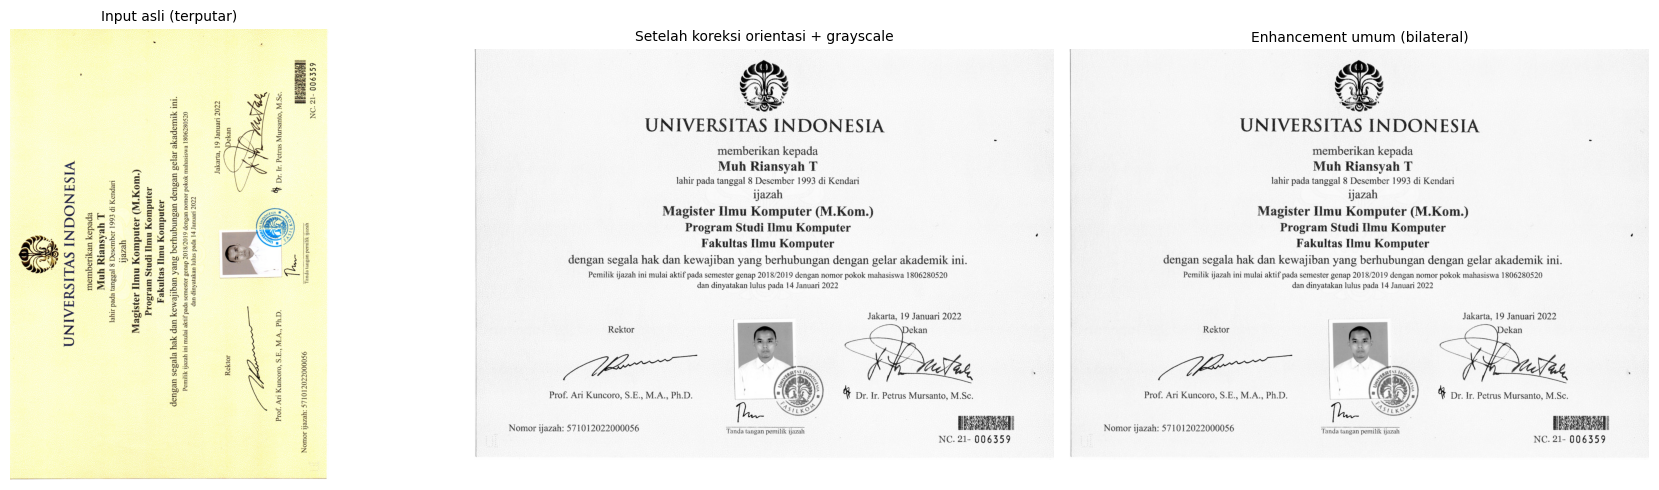

In [4]:
IMG_PATH = os.path.join(DATA_DIR, "ijazah_001.jpg")

raw = cv2.imread(IMG_PATH)
img = fix_orientation(raw)                       # koreksi orientasi
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)     # grayscale
enh  = cv2.bilateralFilter(gray, 5, 25, 5)       # enhancement umum (denoise ringan, tepi tetap tajam)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
show(ax[0], cv2.cvtColor(raw, cv2.COLOR_BGR2RGB), "Input asli (terputar)")
show(ax[1], gray, "Setelah koreksi orientasi + grayscale")
show(ax[2], enh,  "Enhancement umum (bilateral)")
plt.tight_layout(); plt.show()

## 4. Menentukan area nomor ijazah dan area tanda tangan

Kotak merah adalah area nomor, kotak hijau adalah area tanda tangan Rektor. Keduanya dihitung sebagai proporsi gambar, bukan piksel mutlak.

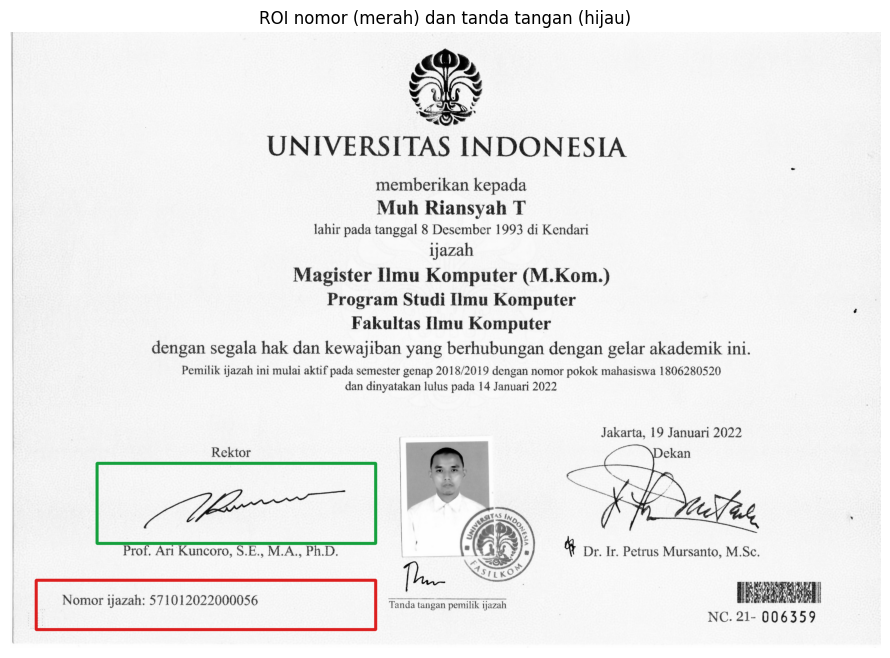

In [5]:
vis = cv2.cvtColor(enh, cv2.COLOR_GRAY2RGB).copy()
H, W = enh.shape
for box, color in [(NUM_BOX, (220, 30, 30)), (SIG_BOX, (20, 160, 60))]:
    x0, x1, y0, y1 = box
    cv2.rectangle(vis, (int(x0 * W), int(y0 * H)), (int(x1 * W), int(y1 * H)), color, 8)
plt.figure(figsize=(12, 8)); plt.imshow(vis); plt.axis("off"); plt.title("ROI nomor (merah) dan tanda tangan (hijau)")
plt.savefig(f"{RESULT_DIR}/roi_overview.png", dpi=110, bbox_inches="tight"); plt.show()

## 5. Eksperimen enhancement area nomor, dibandingkan dengan CER

Satu ijazah bersih hampir selalu terbaca benar oleh semua metode (CER 0 di mana-mana), sehingga tidak ada yang bisa dibandingkan. Karena itu setiap metode diuji pada citra asli **dan** pada 12 kondisi buruk yang disimulasikan: blur (2 level), noise (3 level), kontras rendah, pencahayaan tidak rata (3 level), resolusi rendah, kompresi JPEG berat, dan kemiringan 2,5 derajat. Kondisi noise diulang dengan 3 seed lalu dirata-rata. Semua seed tetap, jadi hasilnya bisa diulang persis.

Ground truth nomor ijazah dibaca dari `data/ground_truth.csv`.

In [6]:
gt_table = pd.read_csv(os.path.join(DATA_DIR, "ground_truth.csv"), dtype=str)
GT = dict(zip(gt_table["filename"], gt_table["nomor_ijazah"]))
gt = GT["ijazah_001.jpg"]
print("Ground truth :", gt)

num_roi = crop(enh, NUM_BOX)
conditions = ["asli", "blur-2", "blur-3.5", "noise-20", "noise-35", "noise-50", "lowcon", "uneven-0.5", "uneven-0.3", "uneven-0.2", "lowres", "jpeg", "miring-2.5"]

rows = {}
for name, fn in METHODS.items():
    rows[name] = {}
    for c in conditions:
        seeds = [0, 1, 2] if c.startswith("noise") else [0]
        scores = []
        for s in seeds:
            try:
                hyp = ocr_number(fn(degrade(num_roi, c, s)))
            except Exception:
                hyp = ""
            scores.append(cer(gt, hyp))
        rows[name][c] = float(np.mean(scores))

cer_df = pd.DataFrame(rows).T
cer_df["CER rata-rata"] = cer_df.mean(axis=1)
cer_df = cer_df.sort_values("CER rata-rata")
cer_df.round(3).to_csv(f"{RESULT_DIR}/cer_table.csv")
cer_df.round(3)

Ground truth : 571012022000056


,asli,blur-2,blur-3.5,noise-20,noise-35,noise-50,lowcon,uneven-0.5,uneven-0.3,uneven-0.2,lowres,jpeg,miring-2.5,CER rata-rata
M9 Blur + BG norm + Upscale + Otsu,0.000,0.000,0.067,0.000,0.000,0.000,0.0,0.0,0.000,0.000,0.0,0.0,0.000,0.005
M10 Median + BG norm + Upscale + Otsu,0.067,0.067,0.133,0.022,0.022,0.022,0.0,0.0,0.000,0.000,0.0,0.0,0.067,0.031
M7 Background norm + Upscale + Otsu,0.000,0.000,0.000,0.000,1.000,1.000,0.0,0.0,0.000,0.000,0.0,0.0,0.000,0.154
M4 Adaptive threshold,0.000,0.000,0.200,1.000,1.000,1.000,0.0,0.0,0.000,0.000,0.0,0.0,0.000,0.246
M3 Gaussian blur + Otsu,0.000,0.000,0.467,0.000,0.000,0.000,0.0,1.0,1.000,1.000,0.0,0.0,0.000,0.267
M6 Denoise (NLM) + CLAHE,0.000,0.000,0.133,0.000,1.000,1.000,0.0,1.0,1.000,0.867,0.0,0.0,0.000,0.385
M5 Sharpening,0.000,0.000,0.000,0.000,1.000,1.000,0.0,1.0,1.000,1.000,0.0,0.0,0.000,0.385
M1 Upscale 2x,0.000,0.000,0.000,0.000,1.000,1.000,0.0,1.0,1.000,1.000,0.0,0.0,0.000,0.385
M0 Grayscale (baseline),0.000,0.000,0.000,0.022,1.000,1.000,0.0,1.0,1.000,1.000,0.0,0.0,0.000,0.386
M2 CLAHE,0.000,0.000,0.067,1.000,1.000,1.000,0.0,1.0,0.333,0.800,0.0,0.0,0.000,0.400


Metode enhancement terbaik (CER rata-rata terendah): M9 Blur + BG norm + Upscale + Otsu
CER rata-rata = 0.005  (baseline M0 = 0.386)


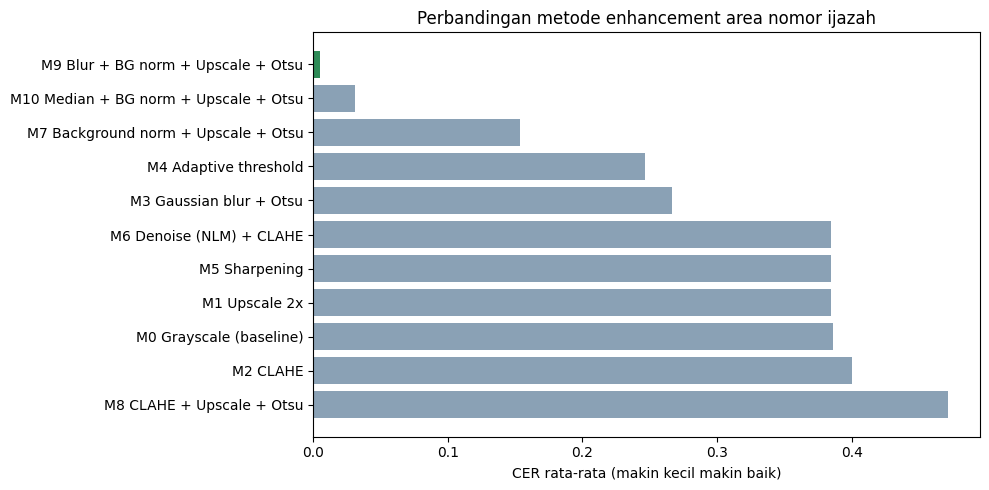

In [7]:
best_method = cer_df.index[0]
print("Metode enhancement terbaik (CER rata-rata terendah):", best_method)
print(f"CER rata-rata = {cer_df.iloc[0]['CER rata-rata']:.3f}  (baseline M0 = {cer_df.loc['M0 Grayscale (baseline)', 'CER rata-rata']:.3f})")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2e8b57" if n == best_method else "#8aa1b5" for n in cer_df.index]
ax.barh(cer_df.index[::-1], cer_df["CER rata-rata"][::-1], color=colors[::-1])
ax.set_xlabel("CER rata-rata (makin kecil makin baik)")
ax.set_title("Perbandingan metode enhancement area nomor ijazah")
plt.tight_layout(); plt.savefig(f"{RESULT_DIR}/cer_comparison.png", dpi=120); plt.show()

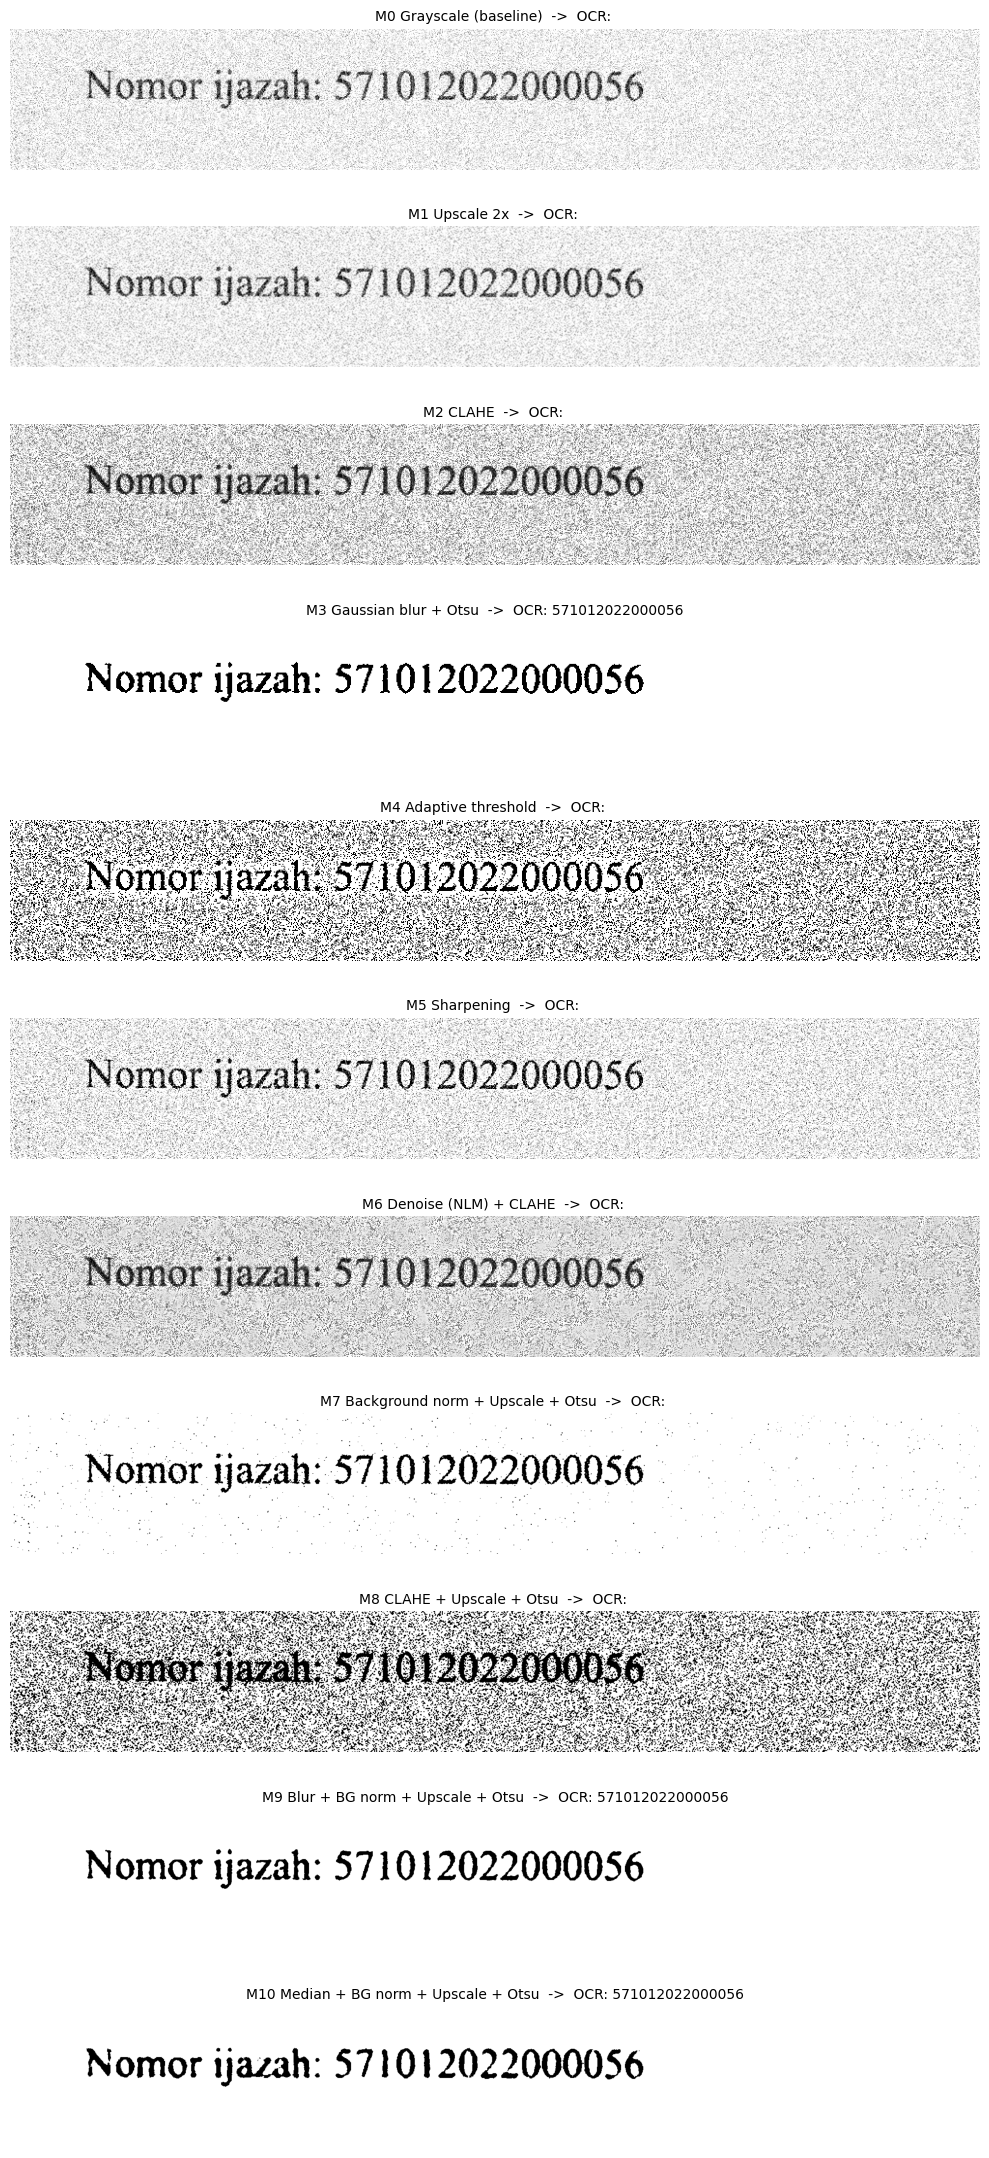

In [8]:
# Contoh visual: bagaimana tiap metode "melihat" area nomor pada kondisi noise-35
sample = degrade(num_roi, "noise-35", 0)
fig, ax = plt.subplots(len(METHODS), 1, figsize=(10, 2.0 * len(METHODS)))
for a, (name, fn) in zip(ax, METHODS.items()):
    out = fn(sample)
    show(a, out, f"{name}  ->  OCR: {ocr_number(out)}")
plt.tight_layout(); plt.savefig(f"{RESULT_DIR}/number_enhancement_samples.png", dpi=110); plt.show()

## 6. Cabang nomor: enhancement terbaik, lalu OCR

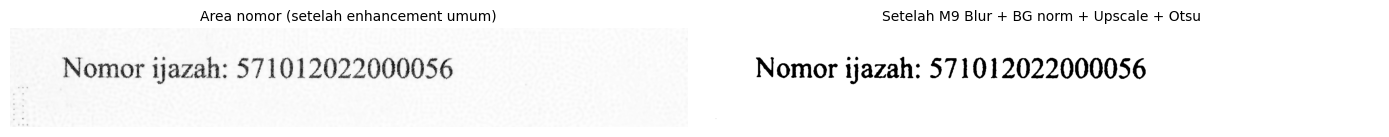

Hasil OCR   : 571012022000056
Ground truth: 571012022000056
CER         : 0.0


In [9]:
final_num_img = METHODS[best_method](num_roi)
nomor = ocr_number(final_num_img)

fig, ax = plt.subplots(1, 2, figsize=(14, 2.6))
show(ax[0], num_roi, "Area nomor (setelah enhancement umum)")
show(ax[1], final_num_img, f"Setelah {best_method}")
plt.tight_layout(); plt.show()
print("Hasil OCR   :", nomor)
print("Ground truth:", gt)
print("CER         :", cer(gt, nomor))

## 7. Cabang tanda tangan: thresholding, morphology, deteksi

Tahapannya dari kiri ke kanan: ROI, estimasi latar, selisih (tinta), thresholding, morphology, dan hasil deteksi dengan kotak pembatas.

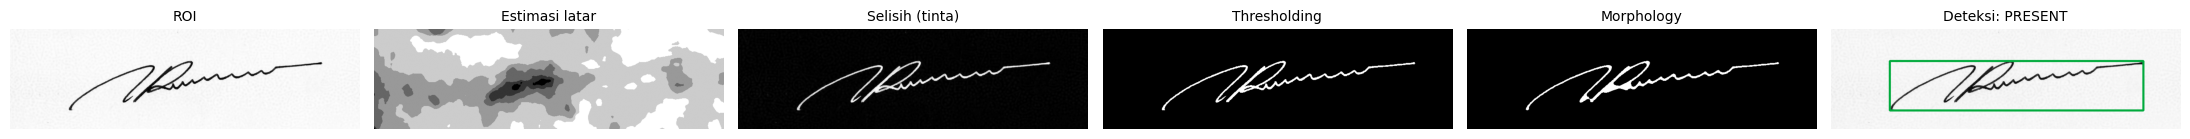

PRESENT {'threshold': 100.0, 'ink_ratio': 0.028, 'largest_area_ratio': 0.028, 'span': 0.7245}


In [10]:
sig_roi = crop(enh, SIG_BOX)
status, info, st = detect_signature(sig_roi)

res = cv2.cvtColor(sig_roi, cv2.COLOR_GRAY2RGB)
if st["bbox"] is not None and status == "PRESENT":
    x, y, bw, bh, _ = st["bbox"]
    cv2.rectangle(res, (x, y), (x + bw, y + bh), (0, 170, 60), 4)

fig, ax = plt.subplots(1, 6, figsize=(22, 3.2))
show(ax[0], sig_roi, "ROI")
show(ax[1], st["background"], "Estimasi latar")
show(ax[2], st["diff"], "Selisih (tinta)")
show(ax[3], st["threshold"], "Thresholding")
show(ax[4], st["morphology"], "Morphology")
show(ax[5], res, f"Deteksi: {status}")
plt.tight_layout(); plt.savefig(f"{RESULT_DIR}/signature_stages.png", dpi=110); plt.show()
print(status, {k: round(v, 4) for k, v in info.items()})

## 8. Fungsi verifikasi lengkap dan hasil akhir

`verifikasi_ijazah(path)` menjalankan seluruh pipeline dari awal sampai akhir, lalu mencetak output dengan format yang diminta.

In [11]:
def verifikasi_ijazah(path, method=None, verbose=True):
    method = method or best_method
    img  = fix_orientation(cv2.imread(path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    enh  = cv2.bilateralFilter(gray, 5, 25, 5)

    nomor = ocr_number(METHODS[method](crop(enh, NUM_BOX)))          # cabang nomor
    status, info, _ = detect_signature(crop(enh, SIG_BOX))            # cabang tanda tangan

    if verbose:
        print(f"Input        : {os.path.basename(path)}")
        print(f"Nomor Ijazah : {nomor}")
        print(f"Tanda Tangan : {status}")
    return dict(file=os.path.basename(path), nomor_ijazah=nomor, tanda_tangan=status, **info)

hasil = verifikasi_ijazah(IMG_PATH)

Input        : ijazah_001.jpg
Nomor Ijazah : 571012022000056
Tanda Tangan : PRESENT


### Uji kasus tanpa tanda tangan

Agar deteksi tidak cuma terbukti di satu arah, dibuat satu ijazah sintetis dengan area tanda tangan Rektor dihapus (diganti warna latar kertas). Sistem seharusnya menjawab `ABSENT`.

In [12]:
base = fix_orientation(cv2.imread(IMG_PATH)).copy()
H, W = base.shape[:2]
x0, x1, y0, y1 = SIG_BOX
sl = (slice(int(y0 * H), int(y1 * H)), slice(int(x0 * W), int(x1 * W)))
patch = base[sl]
bgpatch = np.dstack([cv2.medianBlur(cv2.dilate(patch[..., c], np.ones((25, 25), np.uint8)), 51) for c in range(3)])
base[sl] = bgpatch
NO_SIG = os.path.join(DATA_DIR, "ijazah_002_tanpa_ttd_sintetis.jpg")
cv2.imwrite(NO_SIG, base)
_ = verifikasi_ijazah(NO_SIG)

Input        : ijazah_002_tanpa_ttd_sintetis.jpg
Nomor Ijazah : 571012022000056
Tanda Tangan : ABSENT


### Batch: semua gambar di folder `data/`

Taruh ijazah lain di folder `data/` (format jpg, jpeg, atau png), lalu jalankan sel ini. Kalau nama file ada di `ground_truth.csv`, kolom CER ikut dihitung.

In [13]:
files = sorted(sum([glob.glob(os.path.join(DATA_DIR, e)) for e in ("*.jpg", "*.jpeg", "*.png")], []))
out = []
for f in files:
    r = verifikasi_ijazah(f, verbose=False)
    r["CER"] = round(cer(GT[r["file"]], r["nomor_ijazah"]), 3) if r["file"] in GT else None
    out.append(r)
batch = pd.DataFrame(out)[["file", "nomor_ijazah", "tanda_tangan", "CER"]]
batch.to_csv(f"{RESULT_DIR}/hasil_verifikasi.csv", index=False)
batch

,file,nomor_ijazah,tanda_tangan,CER
0,ijazah_001.jpg,571012022000056,PRESENT,0.0
1,ijazah_002_tanpa_ttd_sintetis.jpg,571012022000056,ABSENT,NaN


## 9. Analisis metode enhancement terbaik

**Pemenang: M9 (Gaussian blur 3x3, normalisasi latar, upscale 2x, lalu Otsu)** dengan CER rata-rata 0,005, jauh di bawah baseline grayscale yang 0,386.

Yang menarik adalah kenapa metode lain kalah, karena polanya konsisten:

- **Normalisasi latar** (M7, M9, M10) kebal terhadap pencahayaan tidak rata. Ijazah hasil foto atau scan miring cahaya hampir pasti punya sisi lebih gelap, dan di kondisi itu metode tanpa penyesuaian latar (M0, M1, M3, M5, M6, M8) gagal dengan CER mendekati 1. Satu-satunya pengecualian adalah M4 (adaptive threshold), karena ambangnya memang dihitung lokal, tetapi M4 runtuh saat ada noise.
- **Normalisasi latar saja belum cukup** (M7). Ia memperkuat selisih terhadap latar, termasuk noise, jadi pada noise sedang dan berat CER-nya melonjak ke 1. Menambah blur ringan sebelum normalisasi (M9) menutup lubang ini.
- **Gaussian blur + Otsu** (M3) tahan noise tetapi Otsu global jatuh begitu pencahayaan tidak rata.
- **CLAHE** (M2, M8) malah memperburuk keadaan, sebab ia ikut menaikkan kontras noise dan pola guilloche pada kertas.
- **Sharpening dan upscale saja** (M5, M1) tidak memberi apa pun dibanding baseline.

Catatan kejujuran: pada citra asli yang bersih hampir semua metode sudah menghasilkan CER 0, jadi keunggulan M9 baru terlihat pada citra yang dirusak. Pengujiannya memakai satu ijazah dengan degradasi simulasi, bukan puluhan ijazah nyata, jadi angka CER ini lebih tepat dibaca sebagai perbandingan relatif antarmetode.

Ringkasan angka di bawah dihitung langsung dari tabel pada bagian 5.

In [14]:
base_cer  = cer_df.loc["M0 Grayscale (baseline)", "CER rata-rata"]
best_cer  = cer_df.iloc[0]["CER rata-rata"]
print(f"Metode terbaik : {best_method}")
print(f"CER rata-rata  : {best_cer:.3f} (baseline grayscale: {base_cer:.3f})")
print()
print("Peringkat metode (CER rata-rata, kecil = bagus):")
for i, (n, v) in enumerate(cer_df["CER rata-rata"].items(), 1):
    print(f"{i}. {n:40s} {v:.3f}")
worst = cer_df.loc[best_method].drop("CER rata-rata").sort_values(ascending=False)
print()
print("Kondisi tersulit untuk metode terbaik:", worst.index[0], f"(CER {worst.iloc[0]:.3f})")

Metode terbaik : M9 Blur + BG norm + Upscale + Otsu
CER rata-rata  : 0.005 (baseline grayscale: 0.386)

Peringkat metode (CER rata-rata, kecil = bagus):
1. M9 Blur + BG norm + Upscale + Otsu       0.005
2. M10 Median + BG norm + Upscale + Otsu    0.031
3. M7 Background norm + Upscale + Otsu      0.154
4. M4 Adaptive threshold                    0.246
5. M3 Gaussian blur + Otsu                  0.267
6. M6 Denoise (NLM) + CLAHE                 0.385
7. M5 Sharpening                            0.385
8. M1 Upscale 2x                            0.385
9. M0 Grayscale (baseline)                  0.386
10. M2 CLAHE                                 0.400
11. M8 CLAHE + Upscale + Otsu                0.472

Kondisi tersulit untuk metode terbaik: blur-3.5 (CER 0.067)
